In [13]:
import importlib
import src.plots
importlib.reload(src.plots)
from src.plots import Plotter

RUNS = ['01_mlp_baseline', '02_small_cnn', '03_regularized_cnn']
plotter = Plotter(project='fer2013-experiments')
hist = plotter.load(RUNS)
print('loaded runs:', list(hist))

loaded runs: ['01_mlp_baseline', '02_small_cnn', '03_regularized_cnn']


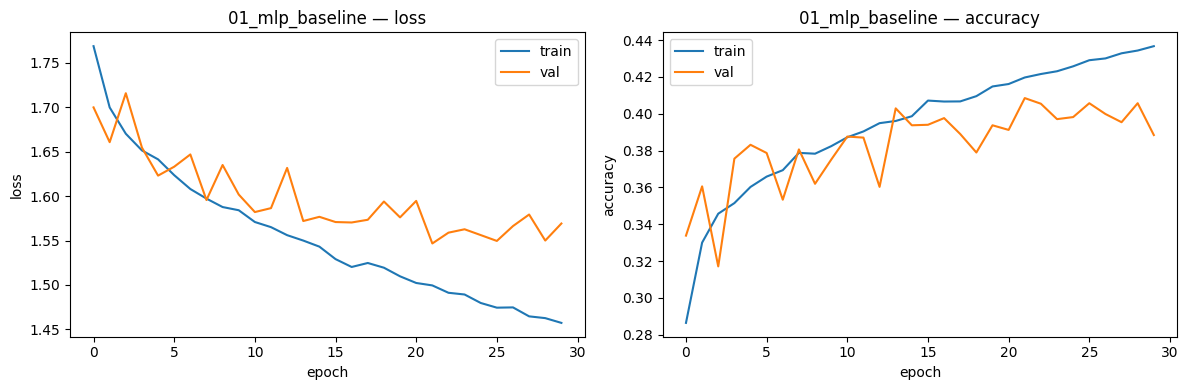

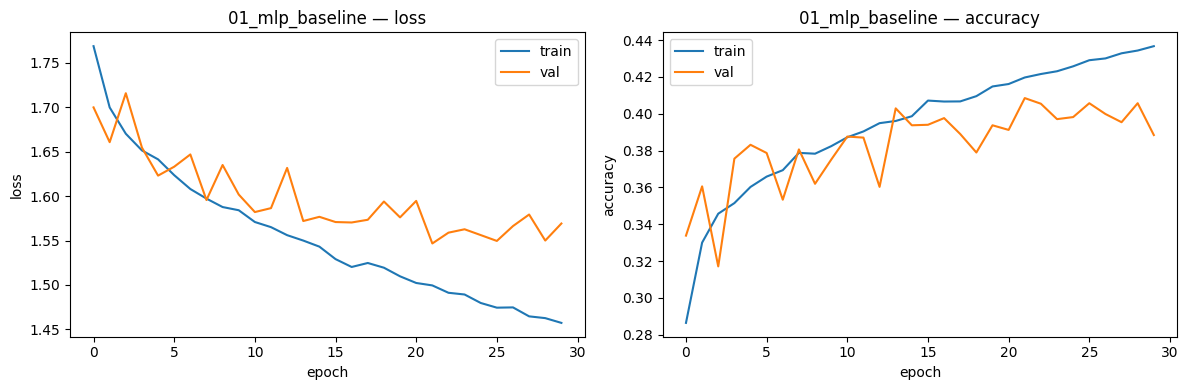

In [14]:
plotter.curves('01_mlp_baseline')

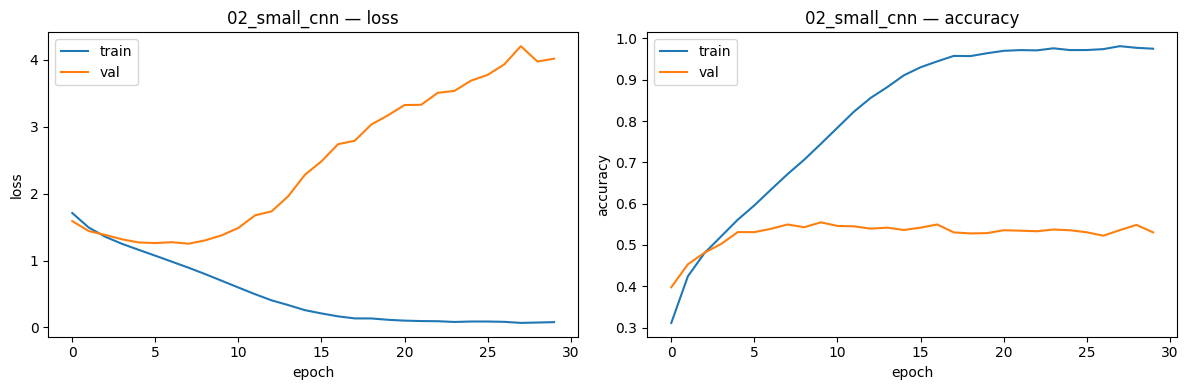

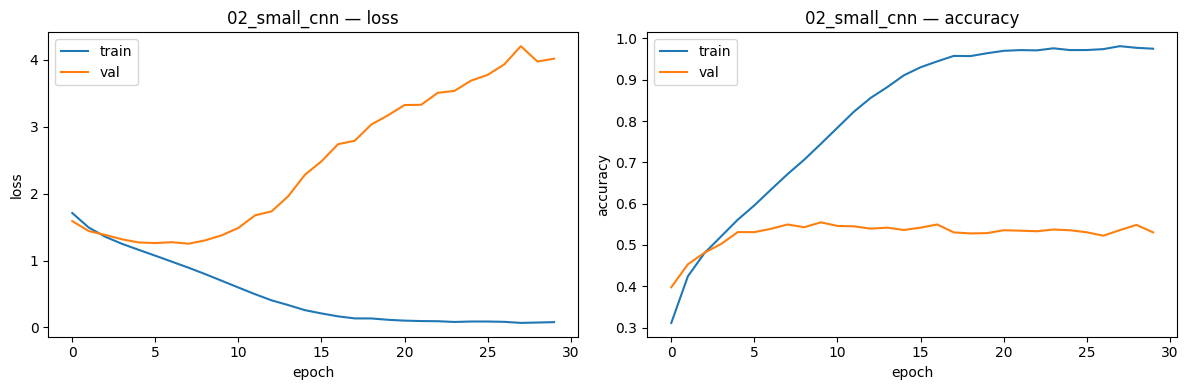

In [15]:
plotter.curves('02_small_cnn')

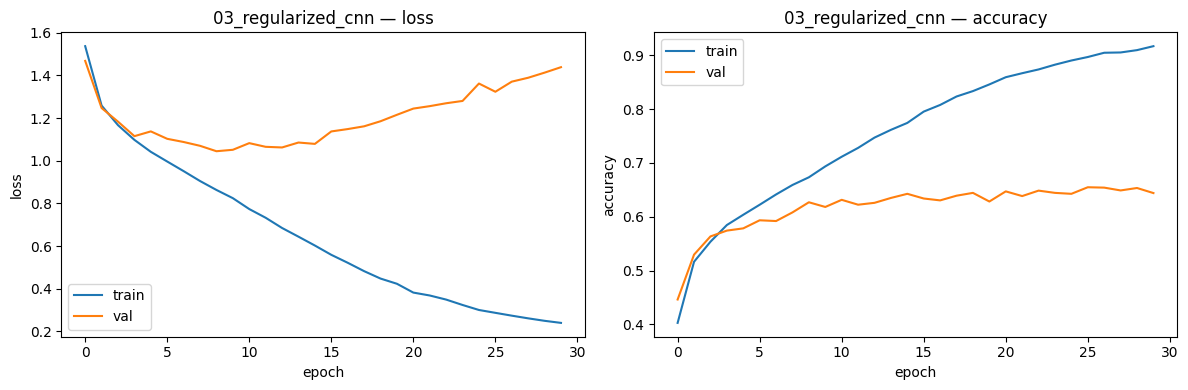

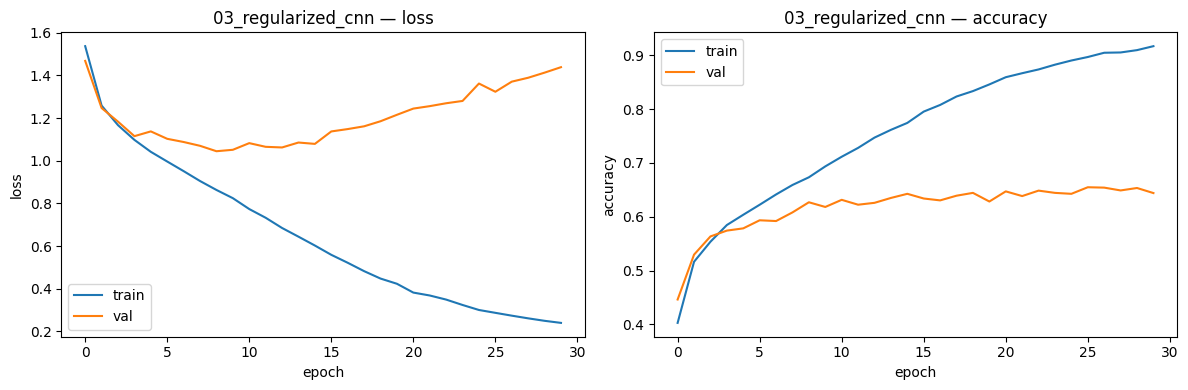

In [16]:
plotter.curves('03_regularized_cnn')

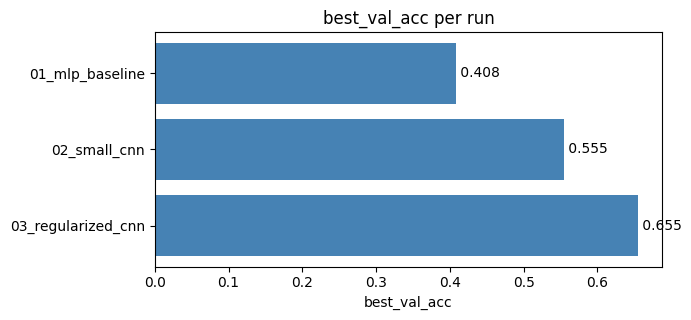

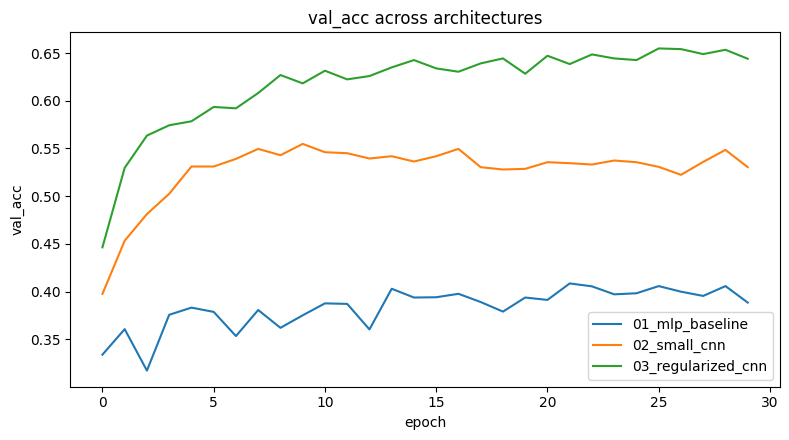

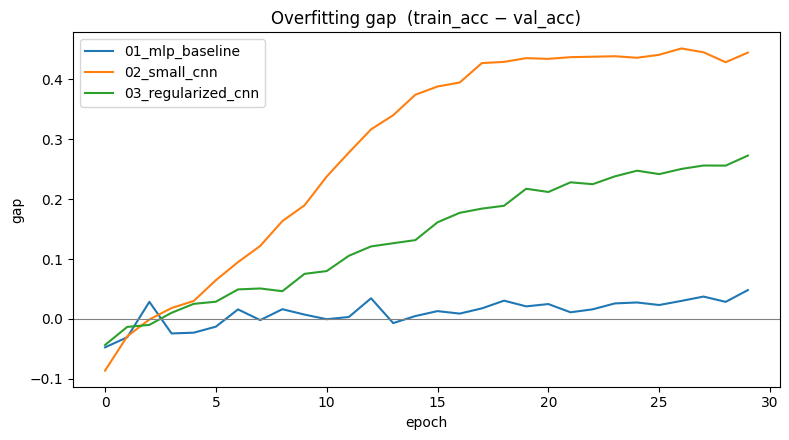

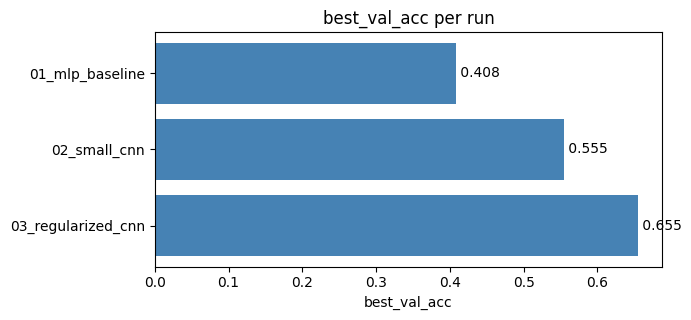

In [17]:
plotter.compare(RUNS, metric='val_acc')
plotter.gap(RUNS)
plotter.best_scores(RUNS)

val accuracy: 0.6548


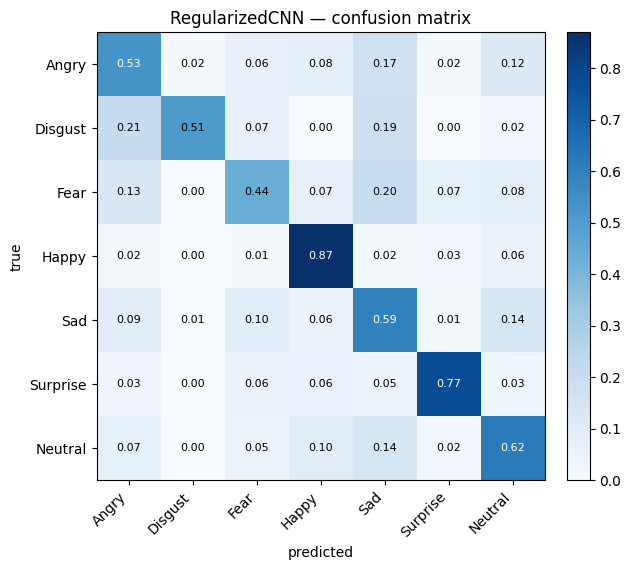

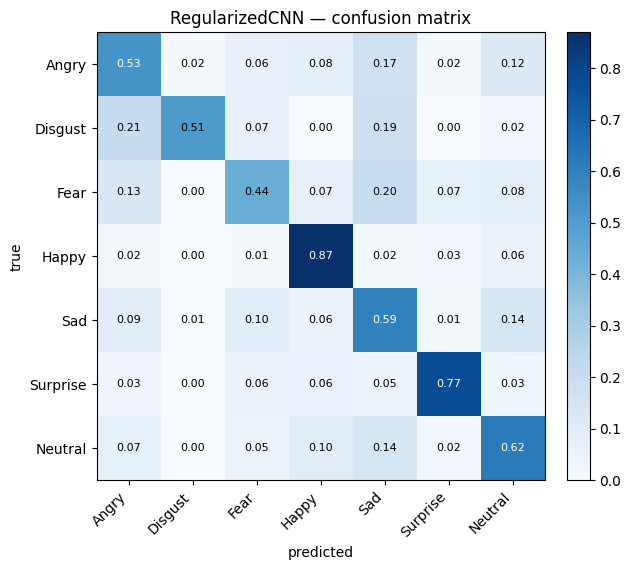

In [18]:
import importlib, src.data, src.models, src.train
for _m in (src.data, src.models, src.train):
    importlib.reload(_m)

import torch, torch.nn as nn
from src.data import get_loaders
from src.models import RegularizedCNN
from src.train import evaluate, DEVICE

_, va = get_loaders('../train.csv', batch_size=64)
model = RegularizedCNN().to(DEVICE)
model.load_state_dict(torch.load('checkpoints/03_regularized_cnn.pt', map_location=DEVICE))
_, acc, preds, ys = evaluate(model, va, nn.CrossEntropyLoss(), return_preds=True)
print('val accuracy:', round(acc, 4))
plotter.confusion(ys, preds, title='RegularizedCNN — confusion matrix')